In [1]:
# Importación de librerías
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Lectura de datos
nivel_del_mar = pd.read_csv("../datos/data-1_metros.csv")
temperatura = pd.read_csv("../datos/data-1_gradoscelsius.csv")
humedad_rel = pd.read_csv("../datos/data-1_porcentaje.csv")
velocidad_viento = pd.read_csv("../datos/data-1_metrosxsegundo.csv")
direccion_viento = pd.read_csv("../datos/data-1_grados.csv")

In [3]:
velocidad_viento

,Tiempo,Rapidez de viento,Velocidad de viento media vectorial,Velocidad de rafaga
0,2026-04-17 16:30:00,5.4,5.5,6.4
1,2026-04-17 16:40:00,4.8,5.4,7.3
2,2026-04-17 16:50:00,5.6,5.7,7.6
3,2026-04-17 17:00:00,4.8,5.5,6.8
4,2026-04-17 17:10:00,4.8,5.5,6.4
...,...,...,...,...
750,2026-04-22 21:30:00,7.1,7.1,8.4
751,2026-04-22 21:40:00,7.4,7.0,8.4
752,2026-04-22 21:50:00,7.7,7.7,8.9
753,2026-04-22 22:00:00,7.6,7.6,8.8


In [4]:
temperatura.iloc[-1]['Temperatura atmosferica']

np.float64(27.2)

In [5]:
humedad_rel.iloc[-1]['Humedad relativa']

np.float64(82.0)

In [6]:
velocidad_viento.iloc[-1]['Velocidad de rafaga']

np.float64(8.9)

In [7]:
# Cambiar el nombre de las columnas en el dataframe 'nivel_del_mar'
nivel_del_mar.rename(columns={'Nivel del mar (radar promedio)':'Radar promedio', 'Nivel del mar (flotador)':'Flotador'},
                    inplace=True)

In [8]:
# Creación de una nueva columna que contiene las fechas del archivo en formato 'datetime'
nivel_del_mar['Tiempo_datetime']=pd.to_datetime(nivel_del_mar['Tiempo'], format='%Y-%m-%d %H:%M:%S')
temperatura['Tiempo_datetime']=pd.to_datetime(temperatura['Tiempo'], format='%Y-%m-%d %H:%M:%S')
humedad_rel['Tiempo_datetime']=pd.to_datetime(humedad_rel['Tiempo'], format='%Y-%m-%d %H:%M:%S')
velocidad_viento['Tiempo_datetime']=pd.to_datetime(velocidad_viento['Tiempo'], format='%Y-%m-%d %H:%M:%S')
direccion_viento['Tiempo_datetime']=pd.to_datetime(direccion_viento['Tiempo'], format='%Y-%m-%d %H:%M:%S')

In [9]:
nivel_del_mar['Radar promedio'].dropna().iloc[-1]

np.float64(1.791)

In [10]:
valor_pronostico=nivel_del_mar.iloc[3580:]
valor_medido=nivel_del_mar.iloc[0:3579]

In [11]:
valor_medido

,Tiempo,Pronostico,Radar promedio,Flotador,Tiempo_datetime
0,2026-04-17 16:25:00,1.758,1.675,1.70,2026-04-17 16:25:00
1,2026-04-17 16:26:00,1.758,1.687,1.70,2026-04-17 16:26:00
2,2026-04-17 16:27:00,1.759,1.708,1.71,2026-04-17 16:27:00
3,2026-04-17 16:28:00,1.759,1.710,1.71,2026-04-17 16:28:00
4,2026-04-17 16:29:00,1.759,1.670,1.72,2026-04-17 16:29:00
...,...,...,...,...,...
3574,2026-04-20 03:59:00,1.167,1.061,1.07,2026-04-20 03:59:00
3575,2026-04-20 04:00:00,1.167,1.056,1.06,2026-04-20 04:00:00
3576,2026-04-20 04:01:00,1.168,1.047,1.07,2026-04-20 04:01:00
3577,2026-04-20 04:02:00,1.168,1.071,1.07,2026-04-20 04:02:00


In [12]:
#nivel_del_mar[nivel_del_mar['Radar promedio'].isna()]
#nivel_del_mar[nivel_del_mar['Radar promedio'].notna()]

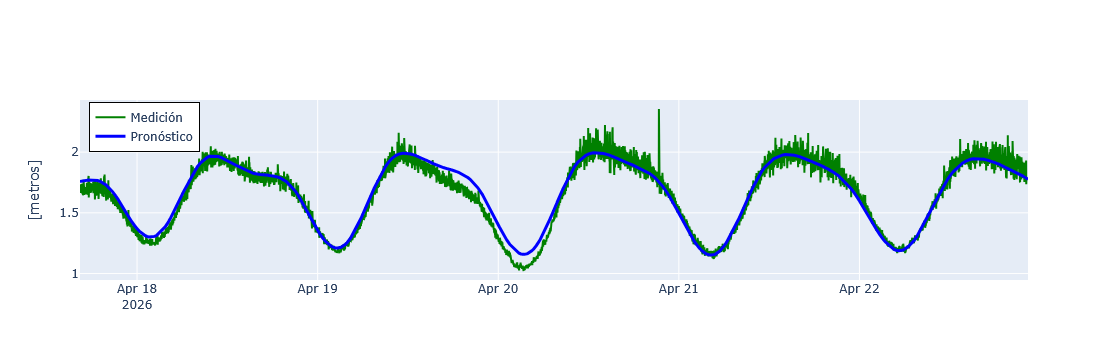

In [13]:
# Grafica nivel del mar
fig=go.Figure()
fig.add_trace(go.Scatter(x=nivel_del_mar['Tiempo_datetime'], y=nivel_del_mar['Radar promedio'],
                         name='Medición', line=dict(color='green',width=2)))
fig.add_trace(go.Scatter(x=nivel_del_mar['Tiempo_datetime'], y=nivel_del_mar['Pronostico'],
                         name='Pronóstico', line=dict(color='blue',width=3)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[metros]", legend=dict(x=0.01, y=0.99,traceorder="normal", font=dict(size=12), bordercolor="Black", 
                                                      borderwidth=1, xanchor="left",yanchor="top"))
fig.show()

## Gráfica Temperatura

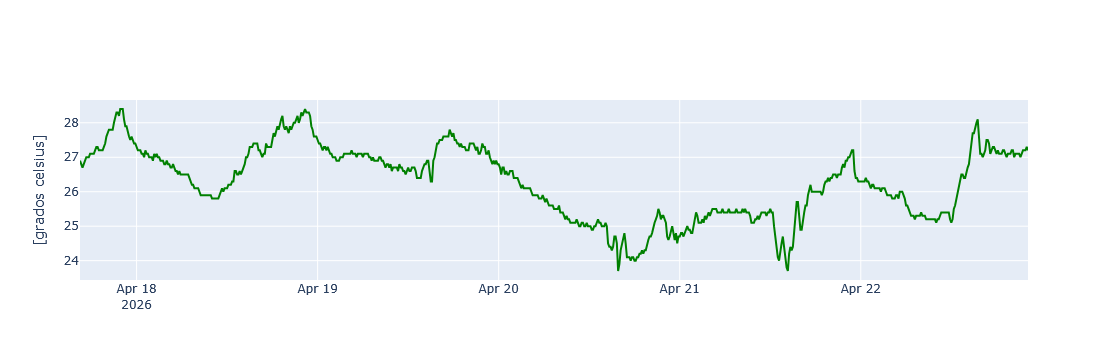

In [14]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=temperatura['Tiempo_datetime'], y=temperatura['Temperatura atmosferica'],
                         name='Medición', line=dict(color='green',width=2)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[grados celsius]")
fig.show()

## Gráfica Humedad Relativa

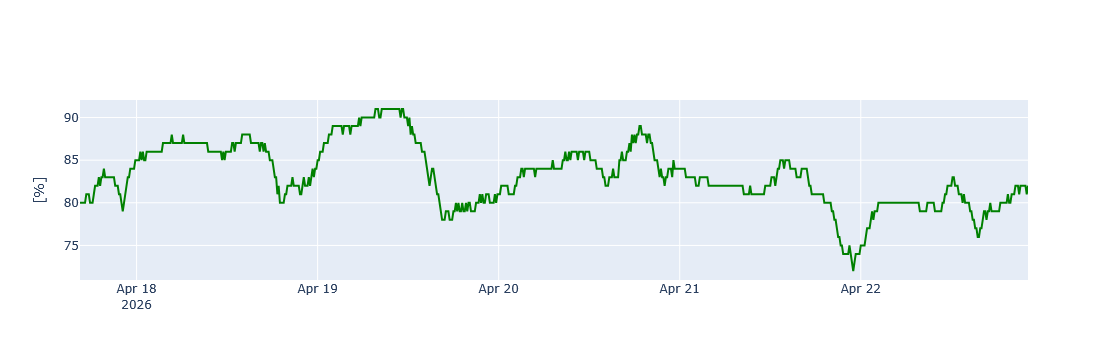

In [15]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=humedad_rel['Tiempo_datetime'], y=humedad_rel['Humedad relativa'],
                         name='Medición', line=dict(color='green',width=2)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[%]")
fig.show()

## Gráfica Viento

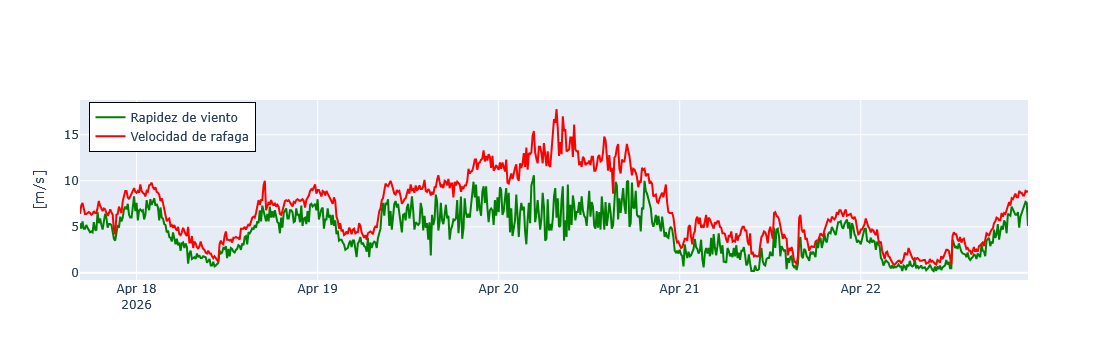

In [16]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=velocidad_viento['Tiempo_datetime'], y=velocidad_viento['Rapidez de viento'],
                         name='Rapidez de viento', line=dict(color='green',width=2)))
fig.add_trace(go.Scatter(x=velocidad_viento['Tiempo_datetime'], y=velocidad_viento['Velocidad de rafaga'],
                         name='Velocidad de rafaga', line=dict(color='red',width=2)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[m/s]", legend=dict(x=0.01, y=0.99, traceorder="normal", font=dict(size=12), bordercolor="Black", 
                                                   borderwidth=1, xanchor="left",yanchor="top"))
fig.show()

## Gráfica de dirección de viento

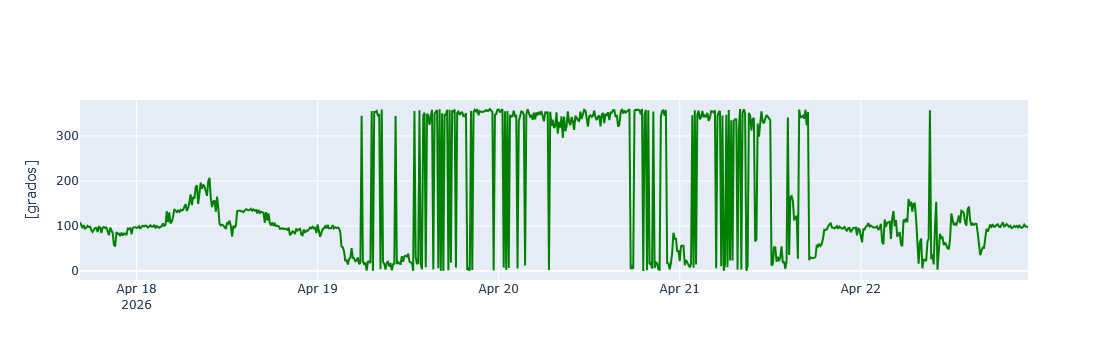

In [17]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=direccion_viento['Tiempo_datetime'], y=direccion_viento['Direccion de rafaga'],
                        line=dict(color='green',width=2)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[grados]")
fig.show()